# Exploração de Dados: Mapeando o comportamento da variável alvo
Notebook focado em responder o que aconteceu a partir do dia 3/09, em que houve um aumento repentino de incidentes que não voltou a diminuir novamente.
Esse notebook da origem as tabelas:
s_volume (volumetria de incidentes)
s_temporal (features temporais)

## Configurações Iniciais

### Configurações a depender do ambiente

In [2]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
ENV_NAME = "☁️ Google Colab" if IN_COLAB else "💻 Ambiente Local (WSL/Jupyter)"

print(f"Detectado: {ENV_NAME}")
print(f"Versão do Python: {sys.version.split()[0]}")

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/1_bronze_data/"
    SAVE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/"
else:
    BASE_PATH = "../1_bronze_data/"
    SAVE_PATH = "../2_silver_data/"

Detectado: ☁️ Google Colab
Versão do Python: 3.12.13
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Importação de Bibliotecas

In [3]:
!pip install ruptures

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pyarrow.csv as pcsv
import pyarrow.dataset as ds
from scipy import stats
from pandas.tseries.holiday import AbstractHolidayCalendar, Holiday, Easter, Day
import ruptures as rpt

### Importação de Dados

In [5]:
pasta_csv = f"{BASE_PATH}b_incidentes.csv"
parse_options = pcsv.ParseOptions(delimiter=";")
read_options = pcsv.ReadOptions(encoding="ISO-8859-1")
dataset = ds.dataset(pasta_csv, format=ds.CsvFileFormat(parse_options=parse_options, read_options=read_options))
df = dataset.to_table().to_pandas()

In [6]:
df.head(5)

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,...,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,Tempo_Pos_Resolução,Resolvido_after_Encerrado,Duração_is_inconsistent,Diferença_Limite_Duração,Modified_Record
0,INC8654273,3 - Média,,,,Team14,IC00001,2025-12-31 23:45:18+00:00,NaT,2025-12-31 23:45:32+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-43186,False
1,INC8654270,4 - Baixa,,,,Team14,IC00002,2025-12-31 23:39:36+00:00,NaT,2025-12-31 23:43:05+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86191,False
2,INC8654264,4 - Baixa,,,,Team14,,2025-12-31 23:23:10+00:00,NaT,2025-12-31 23:25:00+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86290,False
3,INC8654263,4 - Baixa,,,,Team14,,2025-12-31 23:23:07+00:00,NaT,2025-12-31 23:24:57+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86290,False
4,INC8654262,4 - Baixa,,,,Team14,IC00003,2025-12-31 23:23:05+00:00,NaT,2025-12-31 23:23:47+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86358,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   Número                     122543 non-null  object             
 1   Prioridade                 122543 non-null  object             
 2   Produto                    122543 non-null  object             
 3   Categoria                  122543 non-null  object             
 4   Subcategoria               122543 non-null  object             
 5   Grupo designado            122543 non-null  object             
 6   Item de configuração       122543 non-null  object             
 7   Aberto                     122543 non-null  datetime64[ns, UTC]
 8   Resolvido                  40241 non-null   datetime64[ns, UTC]
 9   Encerrado                  122543 non-null  datetime64[ns, UTC]
 10  Duração                    122543 non-null  int64       

In [8]:
# Tamanho do DataFrame
total_registros = len(df)
colunas_originais = df.columns.tolist()
numero_colunas = len(colunas_originais)
print(f"Total de Registros: {total_registros}")
print(f"Total de Colunas: {numero_colunas}")

Total de Registros: 122543
Total de Colunas: 23


### Sobre o DF

In [9]:
coluna_chave = "Número"

colunas_categoricas = [
    "Prioridade", "Produto", "Categoria", "Subcategoria",
    "Grupo designado", "Item de configuração", "Descrição Resumida",
    "Solução", "Aberto por", "Status", "Incidente Pai"
]

colunas_numericas = [
    "Duração",
    "Tempo_Pos_Resolução",
    "Diferença_Limite_Duração"
]

colunas_temporais = ["Aberto", "Resolvido", "Encerrado"]

colunas_validacao = [
    "Duração_is_inconsistent", "Modified_Record",
    "Resolvido_after_Encerrado", "Entrou para KPI?", "KPI Violado?"
]

total_colCat  = len(colunas_categoricas)
total_colNum  = len(colunas_numericas)
total_colTemp = len(colunas_temporais)
total_colVal  = len(colunas_validacao)
total_col = total_colCat + total_colNum + total_colTemp + total_colVal + 1

if total_col == numero_colunas:
    print(f"Total de Colunas: {total_col}")
    print(f"  Numéricas:   {total_colNum}")
    print(f"  Temporais:   {total_colTemp}")
    print(f"  Validação:   {total_colVal}")
    print(f"  Categóricas: {total_colCat}")
else:
    print(f"Faltam classificar {numero_colunas - total_col} colunas, revise.")

Total de Colunas: 23
  Numéricas:   3
  Temporais:   3
  Validação:   5
  Categóricas: 11


In [10]:
# Adicionando coluna prioridade ordinal
prioridade_map = {
    "1 - Crítica":    1,
    "2 - Alta":       2,
    "3 - Média":      3,
    "4 - Baixa":      4,
    "5 - Muito Baixa":5,
}
df["Prioridade_Ordinal"] = df["Prioridade"].map(prioridade_map)

### Período Temporal

In [11]:
data_minima_Aberto    = df["Aberto"].min()
data_maxima_Aberto    = df["Aberto"].max()
data_minima_Resolvido = df["Resolvido"].min()
data_maxima_Resolvido = df["Resolvido"].max()
data_minima_Encerrado = df["Encerrado"].min()
data_maxima_Encerrado = df["Encerrado"].max()

data_minima = min(data_minima_Aberto, data_minima_Resolvido, data_minima_Encerrado)
data_maxima = max(data_maxima_Aberto, data_maxima_Resolvido, data_maxima_Encerrado)
intervalo_total = (data_maxima - data_minima).days

print(f"Data Mínima: {data_minima}")
print(f"Data Máxima: {data_maxima}")
print(f"Intervalo Total: {intervalo_total} dias")

Data Mínima: 2023-01-02 20:19:58+00:00
Data Máxima: 2025-12-31 23:45:32+00:00
Intervalo Total: 1094 dias


## Código Principal

### Calculando Volumetria de Incidentes por dia

In [12]:
# Criando coluna de data
df["data"] = df["Aberto"].dt.date

In [13]:
# Verificando se houveram incidentes todos os dias
df["data"].nunique()

644

In [14]:
# Criando um df diario com o número de incidentes por dia - adicionando os dias em que houveram 0 incidentes
contagem = df.groupby('data').size()
indice_datas_completo = pd.date_range(start=contagem.index.min(), end=contagem.index.max(), freq='D')
contagem_completa = contagem.reindex(indice_datas_completo, fill_value=0)
df_diario = contagem_completa.reset_index()
df_diario.columns = ['data', 'total_incidentes']
df_diario.head()

,data,total_incidentes
0,2023-01-02,1
1,2023-01-03,0
2,2023-01-04,0
3,2023-01-05,0
4,2023-01-06,0


In [15]:
# Adicionando o número de incidentes por prioridade
contagem_por_prioridade = df.groupby(['data', 'Prioridade_Ordinal']).size().unstack(fill_value=0)
contagem_por_prioridade = contagem_por_prioridade.reset_index()
contagem_por_prioridade['data'] = pd.to_datetime(contagem_por_prioridade['data'])
colunas_prioridade = {col: f'total_p{str(col).lower()}' for col in contagem_por_prioridade.columns if col != 'data'}
contagem_por_prioridade = contagem_por_prioridade.rename(columns=colunas_prioridade)
df_diario = df_diario.merge(contagem_por_prioridade, on='data', how='left')
colunas_para_zerar = [col for col in df_diario.columns if col.startswith('total_')]
df_diario[colunas_para_zerar] = df_diario[colunas_para_zerar].fillna(0).astype(int)

In [16]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5
0,2023-01-02,1,0,0,1,0,0
1,2023-01-03,0,0,0,0,0,0
2,2023-01-04,0,0,0,0,0,0
3,2023-01-05,0,0,0,0,0,0
4,2023-01-06,0,0,0,0,0,0


In [17]:
df_diario[["total_incidentes", "total_p1", "total_p2", "total_p3", "total_p4", "total_p5"]].describe()

,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,111.911416,0.000913,14.291324,38.111416,59.203653,0.304110
std,247.021423,0.030220,39.348883,78.287314,155.694844,1.012595
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,107.500000,0.000000,15.000000,62.000000,20.000000,0.000000
max,1431.000000,1.000000,684.000000,849.000000,942.000000,10.000000


In [18]:
# Proporção de incidentes por prioridade
df.groupby('Prioridade_Ordinal').size() / len(df) * 100

,0
Prioridade_Ordinal,
1,0.000816
2,12.770211
3,34.054985
4,52.902247
5,0.271741


#### Calculo de volumetria anual, mensal e incidentes com OLA quebrado

In [19]:
# Calculo de volumetria anual e mensal
df_diario = df_diario.sort_values('data')

df_diario['inc_ac_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['total_incidentes'].cumsum()

df_diario['inc_ac_ano'] = df_diario.groupby(
    df_diario['data'].dt.year
)['total_incidentes'].cumsum()

In [20]:
# Calculo de KPI Violado
df['data'] = pd.to_datetime(df['data'])
df["data"] = df["data"].dt.normalize()
df = df.sort_values('data')
df['is_kpi_violado'] = (df['KPI Violado?'] == 'SIM').astype(int)
df_kpi_violado = pd.DataFrame()
df_kpi_violado['inc_kpi_violado'] = df['is_kpi_violado']
df_kpi_violado['inc_kpi_violado_ac_mes'] = df.groupby([
    df['data'].dt.year,
    df['data'].dt.month
])['is_kpi_violado'].cumsum()
df_kpi_violado['inc_kpi_violado_ac_ano'] = df.groupby(
    df['data'].dt.year
)['is_kpi_violado'].cumsum()
df_kpi_violado.insert(0, 'data', df['data'])

In [21]:
df_kpi_violado[df_kpi_violado['inc_kpi_violado'] >= 1].head()

,data,inc_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano
122529,2023-02-05,1,1,1
122513,2023-04-19,1,1,2
122502,2023-06-12,1,1,3
122499,2023-07-03,1,1,4
122422,2024-02-16,1,1,1


In [22]:
# Merge df_kpi_violado e df_diario
df_diario = pd.merge(df_diario, df_kpi_violado, on='data', how='left')
df_diario.fillna(0, inplace=True)
cols_to_convert = ['inc_kpi_violado', 'inc_kpi_violado_ac_mes', 'inc_kpi_violado_ac_ano']
df_diario[cols_to_convert] = df_diario[cols_to_convert].astype(int)

In [24]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,inc_ac_mes,inc_ac_ano,inc_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano
0,2023-01-02,1,0,0,1,0,0,1,1,0,0,0
1,2023-01-03,0,0,0,0,0,0,1,1,0,0,0
2,2023-01-04,0,0,0,0,0,0,1,1,0,0,0
3,2023-01-05,0,0,0,0,0,0,1,1,0,0,0
4,2023-01-06,0,0,0,0,0,0,1,1,0,0,0


### Mapeamento do Comportamento Cronológico
Ao criar um gráfico de incidentes por dia, poderemos visualizar como a variável alo tem se comportado ao longo do tempo. O que permitirá a identificação de possíveis quebras e tendências.

In [20]:
# Criando gráfico de incidentes por dia em ordem cronológica

for col in ["total_incidentes", "total_p2", "total_p3", "total_p4"]:
  fig = px.line(
      df_diario,
      x='data',
      y=col,
      title=f'<b>Evolução Diária de {col}</b>',
      labels={'data': 'Data', 'incidentes': 'Quantidade de Incidentes'}
  )

  fig.update_traces(
      line=dict(color='#c0392b', width=1.5),
      hovertemplate='<b>Data:</b> %{x|%d/%m/%Y}<br><b>Incidentes:</b> %{y}<extra></extra>'
  )

  fig.update_layout(
      title_font_size=20,
      hovermode='x unified',
      plot_bgcolor='white',
      xaxis=dict(
          showgrid=True,
          gridcolor='#f0f0f0',
          nticks=15,
          tickformat='%b/%y',
          tickangle=45
      ),
      yaxis=dict(
          showgrid=True,
          gridcolor='#f0f0f0'
      ),
      width=1100,
      height=600
  )
  fig.show()
  print("\n")

### Detecção e Validação de Quebras Estruturais

A adoção conjunta da biblioteca Ruptures e do Teste U (Mann-Whitney) cria uma base estatística sólida e imparcial para detectar e validar quebras estruturais (quando a variável mudou bruscamente de comportamento):

- Ruptures (Identificação Algorítmica): Elimina o viés visual humano. Utiliza otimização matemática para mapear a série temporal e cravar as datas exatas onde ocorrem quebras estruturais, segmentando o histórico de incidentes em blocos homogêneos.

- Teste U de Mann-Whitney (Validação Estatística): Atua como o validador definitivo. Como o volume de incidentes nçao segue uma distribuição normal perfeita, este teste é a ferramenta ideal para comparar as médias dos blocos gerados pelo algoritmo, comprovando matematicamente se a quebra é uma mudança real de patamar ou apenas ruído.

In [ ]:
def encontrar_quebras_exatas(df, coluna_data, coluna_valor, n_quebras, min_tamanho=30):
    """
    Encontra um número exato de quebras estruturais em uma série temporal.
    min_tamanho garante que nenhuma quebra ocorra muito perto do fim ou início.
    """
    df_ordenado = df.sort_values(coluna_data).reset_index(drop=True)

    sinal = df_ordenado[coluna_valor].values

    # Algoritmo Dynp (Programação Dinâmica) buscando tamanho mínimo de patamar
    modelo = rpt.Dynp(model="rbf", min_size=min_tamanho).fit(sinal)

    # Prevemos usando o número EXATO de quebras (n_bkps)
    pontos_de_mudanca = modelo.predict(n_bkps=n_quebras)

    # Extraindo índices e datas
    indices_quebra = pontos_de_mudanca[:-1]
    datas_quebra = [df_ordenado[coluna_data].iloc[idx] for idx in indices_quebra]

    return datas_quebra, indices_quebra, sinal, pontos_de_mudanca

# Mapeamento do nome exato da coluna para o número de quebras observadas
config_quebras = {
    'total_p2': 2,
    'total_p3': 2,
    'total_p4': 2,
    'total_incidentes': 2  # Visão geral
}

for coluna, num_quebras_desejadas in config_quebras.items():
  print(f"\n{'-'*40}")
  print(f"--- Analisando Coluna: {coluna.upper()} ---")
  print(f"{'-'*40}")

  datas, indices, sinal, pts = encontrar_quebras_exatas(
      df=df_diario,
      coluna_data='data',
      coluna_valor=coluna,
      n_quebras=num_quebras_desejadas,
      min_tamanho=45
  )

  print(f"Buscando exatamente {num_quebras_desejadas} quebra(s)...")
  for i, data in enumerate(datas, start=1):
      print(f"Quebra {i}: {data.strftime('%d/%m/%Y')} (Índice: {indices[i-1]})")

  print(f"\n--- VALIDAÇÃO ESTATÍSTICA: {coluna.upper()} ---")

  # Adicionamos o índice 0 no início para facilitar o fatiamento dos blocos
  indices_fatiamento = [0] + indices + [len(sinal)]

  for i in range(len(indices)):
      # Definindo onde começa e termina o Bloco A (Antes) e o Bloco B (Depois)
      inicio_bloco_a = indices_fatiamento[i]
      fim_bloco_a = indices_fatiamento[i+1]
      fim_bloco_b = indices_fatiamento[i+2]

      bloco_a = sinal[inicio_bloco_a:fim_bloco_a]
      bloco_b = sinal[fim_bloco_a:fim_bloco_b]

      # Calculando as médias para visão de negócio
      media_a = np.mean(bloco_a)
      media_b = np.mean(bloco_b)

      # Aplicando o Teste de Mann-Whitney (melhor que Teste T para contagens)
      estatistica, p_valor = stats.mannwhitneyu(bloco_a, bloco_b, alternative='two-sided')

      print(f"\nQuebra {i+1} na data: {datas[i].strftime('%d/%m/%Y')}")
      print(f"  Média Antes: {media_a:.2f} incidentes/dia")
      print(f"  Média Depois: {media_b:.2f} incidentes/dia")
      print(f"  P-Valor: {p_valor:.4f}")

      # Interpretando o resultado estatístico (considerando alfa de 5%)
      if p_valor < 0.05:
          print("  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).")
      else:
          print("  Conclusão: ❌ Quebra INVÁLIDA / RUÍDO (As médias não são estatisticamente diferentes).")

  # Plotando os resultados
  fig, ax = rpt.display(sinal, pts, pts)
  plt.title(f"Quebras Estruturais - {coluna.upper()} ({num_quebras_desejadas} quebras)")
  plt.xlabel("Dias")
  plt.ylabel("Qtd. Incidentes")
  plt.show()


----------------------------------------
--- Analisando Coluna: TOTAL_P2 ---
----------------------------------------


In [35]:
# Criando o filtro de quebras pelo total de incidentes
filtro_q1 = df_diario["data"] < pd.to_datetime("2025-01-01")
filtro_q2 = ((df_diario["data"] >= pd.to_datetime("2025-01-01")) & (df_diario["data"] < pd.to_datetime("2025-09-03")))
filtro_q3 = df_diario["data"] >= pd.to_datetime("2025-09-03")

In [59]:
total_dias_q1 = df_diario.loc[filtro_q1].count()
total_dias_q2 = df_diario.loc[filtro_q2].count()
total_dias_q3 = df_diario.loc[filtro_q3].count()
print(f"Total de dias antes da quebra 1: {total_dias_q1.iloc[0]}")
print(f"Total de dias entre a quebra 1 e 2: {total_dias_q2.iloc[0]}")
print(f"Total de dias após após a quebra 2: {total_dias_q3.iloc[0]}")

Total de dias antes da quebra 1: 730
Total de dias entre a quebra 1 e 2: 245
Total de dias após após a quebra 2: 120


In [61]:
# Adicionando coluna
condicoes = [
    filtro_q1,
    filtro_q2,
    filtro_q3
]
valores = [1, 2, 3]
df_diario['comportamento'] = np.select(condicoes, valores, default=0)

In [55]:
df_diario.loc[filtro_q1, "total_incidentes"].describe()

,total_incidentes
count,730.000000
mean,1.002740
std,3.510516
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,69.000000


In [56]:
df_diario.loc[filtro_q2, "total_incidentes"].describe()

,total_incidentes
count,245.000000
mean,124.142857
std,96.460134
min,25.000000
25%,78.000000
50%,120.000000
75%,150.000000
max,1153.000000


In [60]:
df_diario.loc[filtro_q3, "total_incidentes"].describe()

,total_incidentes
count,120.000000
mean,761.633333
std,200.907811
min,369.000000
25%,601.500000
50%,731.000000
75%,882.000000
max,1431.000000


### Criando Métricas para comparação

In [38]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5
0,2023-01-02,1,0,0,1,0,0
1,2023-01-03,0,0,0,0,0,0
2,2023-01-04,0,0,0,0,0,0
3,2023-01-05,0,0,0,0,0,0
4,2023-01-06,0,0,0,0,0,0


#### Métricas Temporais
Serão utilizadas para identificação de sazonalidades
- feriado - boleano (feriados nacionais)
- dia_sem - dia da semana (será aplicado ordinal encoding)
- dia_util - dia da semana que não é final de semana nem feriado
- mes - número do mês
- trimestre - número do trimestre

In [52]:
class CalendarioSazonalidadeBR(AbstractHolidayCalendar):
    rules = [
        Holiday('Ano Novo', month=1, day=1),
        Holiday('Aniversário de São Paulo', month=1, day=25),
        Holiday('Carnaval (Segunda)', month=1, day=1, offset=[Easter(), Day(-48)]),
        Holiday('Carnaval (Terça)', month=1, day=1, offset=[Easter(), Day(-47)]),
        Holiday('Quarta-feira de Cinzas', month=1, day=1, offset=[Easter(), Day(-46)]),
        Holiday('Sexta-feira Santa', month=1, day=1, offset=[Easter(), Day(-2)]),
        Holiday('Tiradentes', month=4, day=21),
        Holiday('Dia do Trabalho', month=5, day=1),
        Holiday('Corpus Christi', month=1, day=1, offset=[Easter(), Day(60)]),
        Holiday('Independência do Brasil', month=9, day=7),
        Holiday('Nossa Senhora Aparecida', month=10, day=12),
        Holiday('Finados', month=11, day=2),
        Holiday('Proclamação da República', month=11, day=15),
        Holiday('Consciência Negra', month=11, day=20),
        Holiday('Natal', month=12, day=25)
    ]

cal = CalendarioSazonalidadeBR()

feriados = cal.holidays(
    start=data_minima,
    end=data_maxima,
    return_name=True
)
feriados.index = feriados.index.tz_localize(None)
df_diario['nome_feriado'] = df_diario['data'].map(feriados).fillna('')
df_diario['feriado'] = df_diario['data'].isin(feriados.index).astype(int)
df_diario.loc[df_diario['feriado'] == 1].sample(5)

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,nome_feriado,feriado
1053,2025-11-20,816,0,243,56,517,0,Consciência Negra,1
514,2024-05-30,0,0,0,0,0,0,Corpus Christi,1
837,2025-04-18,67,0,14,41,12,0,Sexta-feira Santa,1
683,2024-11-15,0,0,0,0,0,0,Proclamação da República,1
840,2025-04-21,49,0,15,19,15,0,Tiradentes,1


In [53]:
# Outras features
df_diario['dia_semana'] = df_diario['data'].dt.dayofweek
df_diario['dia_util'] = ((df_diario['dia_semana'] < 5) & (df_diario['feriado'] == 0)).astype(int)
df_diario['mes'] = df_diario['data'].dt.month
df_diario['trimestre'] = df_diario['data'].dt.quarter
df_diario.sample(5)

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre
893,2025-06-13,91,0,9,58,24,0,,0,4,1,6,2
89,2023-04-01,0,0,0,0,0,0,,0,5,0,4,2
916,2025-07-06,25,0,5,11,9,0,,0,6,0,7,3
990,2025-09-18,600,0,66,165,369,0,,0,3,1,9,3
122,2023-05-04,0,0,0,0,0,0,,0,3,1,5,2


In [54]:
# Dia do mês
df_diario['dia_mes'] = df_diario['data'].dt.day
# Dia util do mes
df_diario['num_dia_util'] = (
    df_diario[df_diario['dia_util'] == 1]
    .groupby([df_diario['data'].dt.year, df_diario['data'].dt.month])['dia_util']
    .cumsum()
)
df_diario['num_dia_util'] = df_diario['num_dia_util'].fillna(0).astype(int)
df_diario.sample(5)

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre,dia_mes,num_dia_util
599,2024-08-23,1,0,0,1,0,0,,0,4,1,8,3,23,17
28,2023-01-30,2,0,0,2,0,0,,0,0,1,1,1,30,20
216,2023-08-06,0,0,0,0,0,0,,0,6,0,8,3,6,0
988,2025-09-16,597,0,42,174,381,0,,0,1,1,9,3,16,12
307,2023-11-05,1,0,0,1,0,0,,0,6,0,11,4,5,0


In [68]:
# Tipo Dia
condicoes_tipo = [(df_diario['feriado'] == 1) | (df_diario['dia_semana'] >= 5)]
categorias = ['Fim de semana/Feriado']
df_diario['tipo_dia'] = np.select(condicoes_tipo, categorias, default='Dia Útil')

#### Métricas a partir de dados categoricos

In [ ]:
# Nova coluna no df de incidentes identificando o comportamento


In [ ]:
# Número único de itens de configuração

In [ ]:
# Número de incidentes abertos Manual X Monitoramento

In [ ]:
# Número de incidentes com

### Comparação do período de 2025 antes e depois de 03/09/2025

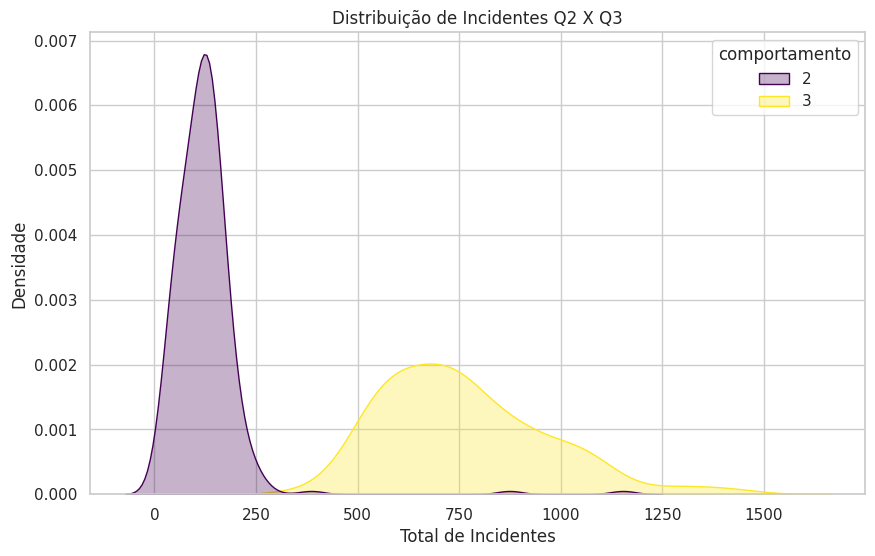

In [65]:
# Incidentes X Período
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_diario[df_diario['comportamento']>1],
    x="total_incidentes",
    hue="comportamento",
    fill=True,
    common_norm=False,
    palette="viridis",
    alpha=0.3
)

plt.title("Distribuição de Incidentes Q2 X Q3")
plt.xlabel("Total de Incidentes")
plt.ylabel("Densidade")
plt.show()

#### Comparando Sazonalidade
Foi realizada a comparação de dia util e final de semana/ feriado, e também a de dias da semana. Não foram realizadas análises de mês e trimestre, pois não há como comparar os dois de forma justa.

Tabela de Crescimento (Razão entre Q3 e Q2):
comportamento                   2           3  fator_crescimento
tipo_dia                                                        
Dia Útil               152.245509  802.357143           5.270153
Fim de semana/Feriado   63.974359  666.611111          10.419973


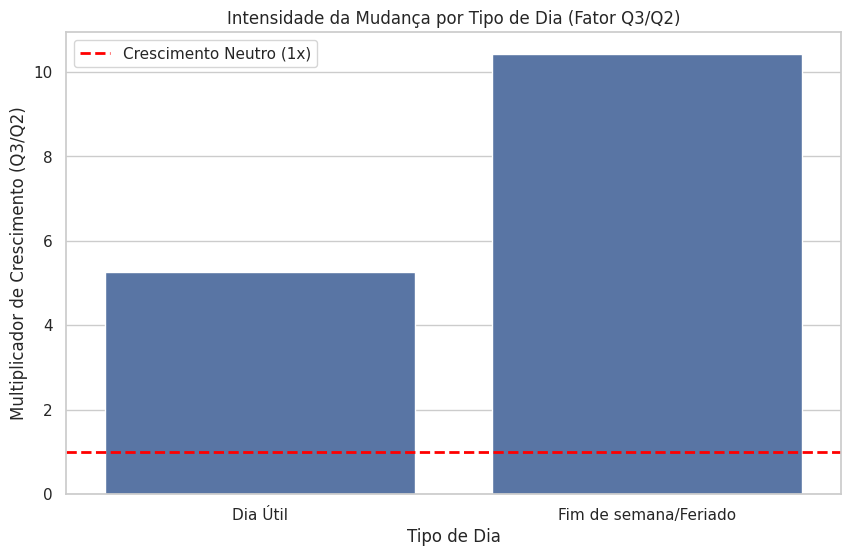

In [81]:
# Comparação Final de Semana X Feriado
df_agrupado = df_diario.groupby(['comportamento', 'tipo_dia', 'data'])['total_incidentes'].sum().reset_index()
df_taxa = df_agrupado.groupby(['comportamento', 'tipo_dia'])['total_incidentes'].mean().reset_index()

df_pivot = df_taxa[df_taxa['comportamento'].isin([2, 3])].pivot(
    index='tipo_dia', columns='comportamento', values='total_incidentes'
)
df_pivot['fator_crescimento'] = df_pivot[3] / df_pivot[2]

print("Tabela de Crescimento (Razão entre Q3 e Q2):")
print(df_pivot)

# Plotagem do Gráfico de Barras do Fator de Crescimento
plt.figure(figsize=(10, 6))

sns.barplot(
    x=df_pivot.index,
    y=df_pivot['fator_crescimento'],
)

# Linha de referência no 1.0 (crescimento neutro)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')

plt.title("Intensidade da Mudança por Tipo de Dia (Fator Q3/Q2)")
plt.ylabel("Multiplicador de Crescimento (Q3/Q2)")
plt.xlabel("Tipo de Dia")
plt.legend()
plt.show()

Tabela de Crescimento (Razão entre Q3 e Q2):
comportamento                   2           3  fator_crescimento
tipo_dia                                                        
Dia Útil               152.245509  802.357143           5.270153
Fim de semana/Feriado   63.974359  666.611111          10.419973


Fator de Crescimento por Dia da Semana (Q3 em relação a Q2):
comportamento           2           3  fator_crescimento
Seg            158.060606  802.058824           5.074375
Ter            168.588235  797.588235           4.730984
Qua            150.757576  819.666667           5.436985
Qui            159.727273  781.066667           4.890002
Sex            124.441176  807.882353           6.492082


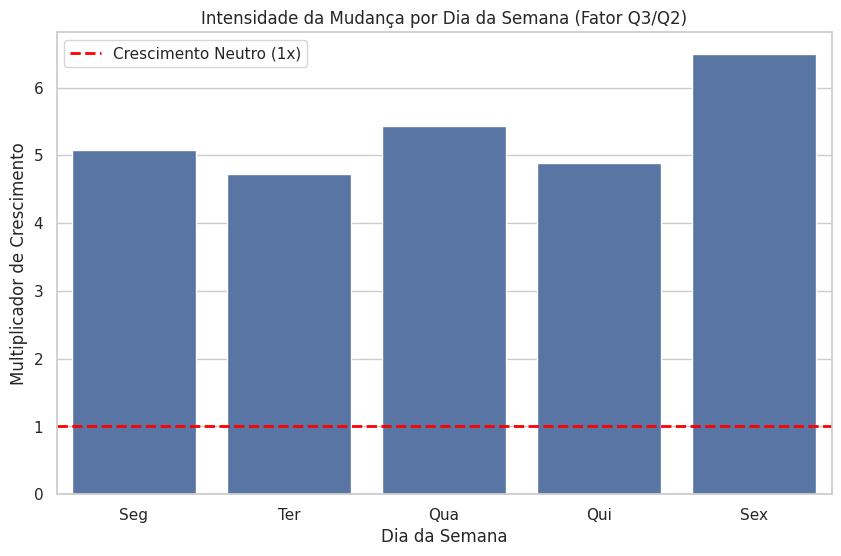

In [79]:
# Comparando dias úteis da semana
df_uteis = df_diario[(df_diario['comportamento'].isin([2, 3])) & (df_diario['dia_util'] == 1)].copy()

df_taxa_uteis = df_uteis.groupby(['comportamento', 'dia_semana'])['total_incidentes'].mean().reset_index()

df_pivot_uteis = df_taxa_uteis.pivot(index='dia_semana', columns='comportamento', values='total_incidentes')

df_pivot_uteis['fator_crescimento'] = df_pivot_uteis[3] / df_pivot_uteis[2]

df_pivot_uteis.index = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex']
print("Fator de Crescimento por Dia da Semana (Q3 em relação a Q2):")
print(df_pivot_uteis)

plt.figure(figsize=(10, 6))

# Plotando as barras
sns.barplot(
    x=df_pivot_uteis.index,
    y=df_pivot_uteis['fator_crescimento']
)

# Adicionando uma linha horizontal no 1.0 (que representa estabilidade)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')

plt.title("Intensidade da Mudança por Dia da Semana (Fator Q3/Q2)")
plt.ylabel("Multiplicador de Crescimento")
plt.xlabel("Dia da Semana")
plt.legend()
plt.show()

In [ ]:
sns.histplot(dados, kde=True, color='purple')
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

### Dados categóricos

In [ ]:
freq_dict = {}

for col in colunas_categoricas:
    freq_dict[col] = (
        df.groupby(col, dropna=False)
        .size()
        .reset_index(name="count")
        .assign(percentual=lambda x: (x["count"] / total_registros * 100).round(2))
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

print(f"Frequência por valor gerada para as colunas: {list(freq_dict.keys())}")

In [ ]:
stats_data = []

for col_name in colunas_categoricas:
    nulls    = df[col_name].isna().sum()
    distintos = df[col_name].nunique()
    pct_nulls = round(nulls / total_registros * 100, 2) if total_registros > 0 else 0.0
    stats_data.append({
        "coluna": col_name,
        "total_registros": total_registros,
        "distintos": distintos,
        "nulos": int(nulls),
        "pct_nulls": pct_nulls,
    })

df_info_cat = pd.DataFrame(stats_data).sort_values(["nulos","distintos"]).reset_index(drop=True)
display(df_info_cat)

In [ ]:
display(freq_dict['Aberto por'])

In [ ]:
display(freq_dict['Prioridade'])

In [ ]:
display(freq_dict['Status'])

In [ ]:
display(freq_dict['Grupo designado'])

Informações gerais

A maior parte dos incidentes são P4, seguidos por P3 e P2. As classes minoritárias são P5 e P1 - com menos de 1% de representatividade na base. Inclusive, no período analisado, só teve 1 P1.

Não há muitos incidentes abertos de forma manual, isso é um bom indicador. Precisamos entender por que e o que faz um incidente ser aberto manualmente.

A maior parte dos incidentes são encerrados automaticamente ou não têm intervenção.

A esmagadora maioria dos incidentes é resolvida pelo Time 14.